# mROSE sequence generation demo

This notebook runs compact mROSE generation examples for the three major mRNA regions and shows only the key results. The checked-in outputs were generated on the project server with the released checkpoints.


<p align="center">
  <img src="../docs/assets/mrose-icon.png" alt="mROSE icon" width="150">
</p>

<p align="center">
  <img src="../docs/assets/mrose-figure1.png" alt="mROSE workflow" width="900">
</p>


## 1. Setup

The notebook assumes it is run from either the repository root or the `notebooks/` directory. Generation logs are captured internally so the visible output stays focused on results.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
if (cwd / "mrose").is_dir():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "mrose").is_dir():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



## 2. Readiness check

Only essential readiness information is shown. Checkpoint file sizes are intentionally omitted from the notebook output.


In [2]:
import importlib.util

required_modules = ["numpy", "pandas", "torch", "Bio", "sklearn", "scipy", "tqdm"]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
vienna_ready = importlib.util.find_spec("ViennaRNA") is not None or importlib.util.find_spec("RNA") is not None

checkpoint_paths = {
    "5' UTR": PROJECT_ROOT / "generation" / "5utr" / "Model.pth",
    "CDS": PROJECT_ROOT / "generation" / "cds" / "Model.pth",
    "3' UTR": PROJECT_ROOT / "generation" / "3utr" / "Model.pth",
}
missing_checkpoints = [name for name, path in checkpoint_paths.items() if not path.exists()]

print("Environment:", "ready" if not missing_modules else "missing " + ", ".join(missing_modules))
print("RNA folding:", "ready" if vienna_ready else "not available")
print("Checkpoints:", "ready" if not missing_checkpoints else "missing " + ", ".join(missing_checkpoints))


Environment: ready
RNA folding: ready
Checkpoints: ready


## 3. Run compact generation demos

The commands below generate 20 candidates per region and keep the top 5. Verbose command-line logs are saved internally and summarized after each task.


In [3]:
TASKS = {
    "5' UTR": {
        "script": PROJECT_ROOT / "generation" / "5utr" / "generate_5utr.py",
        "checkpoint": PROJECT_ROOT / "generation" / "5utr" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "5utr_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "5utr_demo",
        "args": ["--num_samples", "20", "--top_k", "5", "--device", "cpu", "--output_prefix", "demo_5utr"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "5utr_demo" / "demo_5utr_top5.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "5utr_demo" / "demo_5utr_all_scored.csv",
    },
    "CDS": {
        "script": PROJECT_ROOT / "generation" / "cds" / "generate_cds.py",
        "checkpoint": PROJECT_ROOT / "generation" / "cds" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "cds_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "cds_demo",
        "args": ["--num_samples", "20", "--top_k", "5", "--device", "cpu", "--mfe_weight", "0"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "cds_demo" / "top10_generated_scored.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "cds_demo" / "all_generated_scored.csv",
    },
    "3' UTR": {
        "script": PROJECT_ROOT / "generation" / "3utr" / "generate_3utr.py",
        "checkpoint": PROJECT_ROOT / "generation" / "3utr" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "3utr_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "3utr_demo",
        "args": ["--num_samples", "20", "--top_k", "5", "--device", "cpu", "--match_input_length", "--output_prefix", "demo_3utr"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "3utr_demo" / "demo_3utr_top5.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "3utr_demo" / "demo_3utr_all_scored.csv",
    },
}

run_logs = {}
for region, cfg in TASKS.items():
    cfg["output_dir"].mkdir(parents=True, exist_ok=True)
    command = [
        sys.executable,
        str(cfg["script"]),
        "--checkpoint", str(cfg["checkpoint"]),
        "--input_fasta", str(cfg["input_fasta"]),
        "--output_dir", str(cfg["output_dir"]),
        *cfg["args"],
    ]
    run_env = os.environ.copy()
    run_env.setdefault("MKL_THREADING_LAYER", "GNU")
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        env=run_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )
    run_logs[region] = result.stdout
    if result.returncode != 0:
        print(run_logs[region])
        raise RuntimeError(f"{region} generation failed with exit code {result.returncode}")
    print(f"{region}: generated top candidates -> {cfg['top_csv'].relative_to(PROJECT_ROOT)}")


5' UTR: generated top candidates -> outputs/generation/5utr_demo/demo_5utr_top5.csv
CDS: generated top candidates -> outputs/generation/cds_demo/top10_generated_scored.csv
3' UTR: generated top candidates -> outputs/generation/3utr_demo/demo_3utr_top5.csv


## 4. Result tables

The tables show the top candidates with only the most useful design metrics. Long sequences are shortened for readability.


In [4]:
def shorten_sequence(sequence, width=42):
    sequence = str(sequence)
    if len(sequence) <= width:
        return sequence
    flank = max(8, (width - 3) // 2)
    return f"{sequence[:flank]}...{sequence[-flank:]}"


def standardize_region_table(region, path):
    df = pd.read_csv(path).head(5).copy()
    df.insert(0, "region", region)
    if "rank" not in df.columns:
        df.insert(1, "rank", np.arange(1, len(df) + 1))
    if region == "5' UTR":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["mrl_pred"],
            "primary_label": "MRL",
            "gc": df["GC"],
            "mfe": df["mfe"],
            "length": df["sequence"].astype(str).str.len(),
            "sequence": df["sequence"],
        })
    elif region == "CDS":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["pred_value"],
            "primary_label": "pred_value",
            "gc": df["gc"],
            "mfe": df["MFE"],
            "length": df["length_nt"],
            "sequence": df["sequence"],
        })
    else:
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["pred_value"],
            "primary_label": "degradation_pred",
            "gc": df["GC"],
            "mfe": df["MFE"],
            "length": df["length"],
            "sequence": df["sequence"],
        })
    out["sequence_preview"] = out["sequence"].map(shorten_sequence)
    return out

region_tables = [standardize_region_table(region, cfg["top_csv"]) for region, cfg in TASKS.items()]
summary = pd.concat(region_tables, ignore_index=True)
summary_view = summary[["region", "rank", "final_score", "primary_label", "primary_metric", "gc", "mfe", "length", "sequence_preview"]].copy()
for col in ["final_score", "primary_metric", "gc", "mfe"]:
    summary_view[col] = summary_view[col].astype(float).round(4)
print(summary_view.to_string(index=False))


region  rank  final_score    primary_label  primary_metric     gc   mfe  length                          sequence_preview
5' UTR     1       0.8305              MRL          6.1878 0.5200  -4.1      50 AGGTACCCGTGAATTTTAA...CCAGACTACCACCGCCACC
5' UTR     2       0.7615              MRL          5.9297 0.5472  -4.9      53 AGGACTACTTCTGGTTACT...CACCCTTCTAGCAGCCACC
5' UTR     3       0.7435              MRL          5.9514 0.5472  -8.6      53 AGGAAGGGTCAAAAGTAGG...TATAGATTGCGCAGCCACC
5' UTR     4       0.5936              MRL          5.4745 0.6296 -12.7      54 AGGACCACAATATAGGCAG...GGGGCTCCGCGTGGCCACC
5' UTR     5       0.5862              MRL          5.3419 0.5690  -9.6      58 AGGAGTTTTCAAGAGTCCG...GCGTGCTCAGGGAGCCACC
   CDS     1       0.8216       pred_value          0.6070 0.5556 -36.7     117 ATGGCGGAAGAGTTGTTCA...AACCGAGGCGGCCGAATAA
   CDS     2       0.7518       pred_value          0.5348 0.5641 -36.4     117 ATGGCCGAAGAGTTGTTCA...GACCGAAGCGGCCGAATAA
   CDS     3       0.737

## 5. Best candidate per region


In [5]:
best = summary.sort_values(["region", "rank"]).groupby("region", sort=False).head(1).copy()
best_view = best[["region", "final_score", "primary_label", "primary_metric", "gc", "mfe", "length", "sequence_preview"]].copy()
for col in ["final_score", "primary_metric", "gc", "mfe"]:
    best_view[col] = best_view[col].astype(float).round(4)
print(best_view.to_string(index=False))


region  final_score    primary_label  primary_metric     gc   mfe  length                          sequence_preview
3' UTR       0.7160 degradation_pred          0.2188 0.5269 -15.2      93 ACAGCCCGACGAGATCAGC...CATGGCAAGGCATAAAAAG
5' UTR       0.8305              MRL          6.1878 0.5200  -4.1      50 AGGTACCCGTGAATTTTAA...CCAGACTACCACCGCCACC
   CDS       0.8216       pred_value          0.6070 0.5556 -36.7     117 ATGGCGGAAGAGTTGTTCA...AACCGAGGCGGCCGAATAA


## 6. Visual summary

The figures compare the top candidates across regions. Higher final score is better for the configured scoring functions.


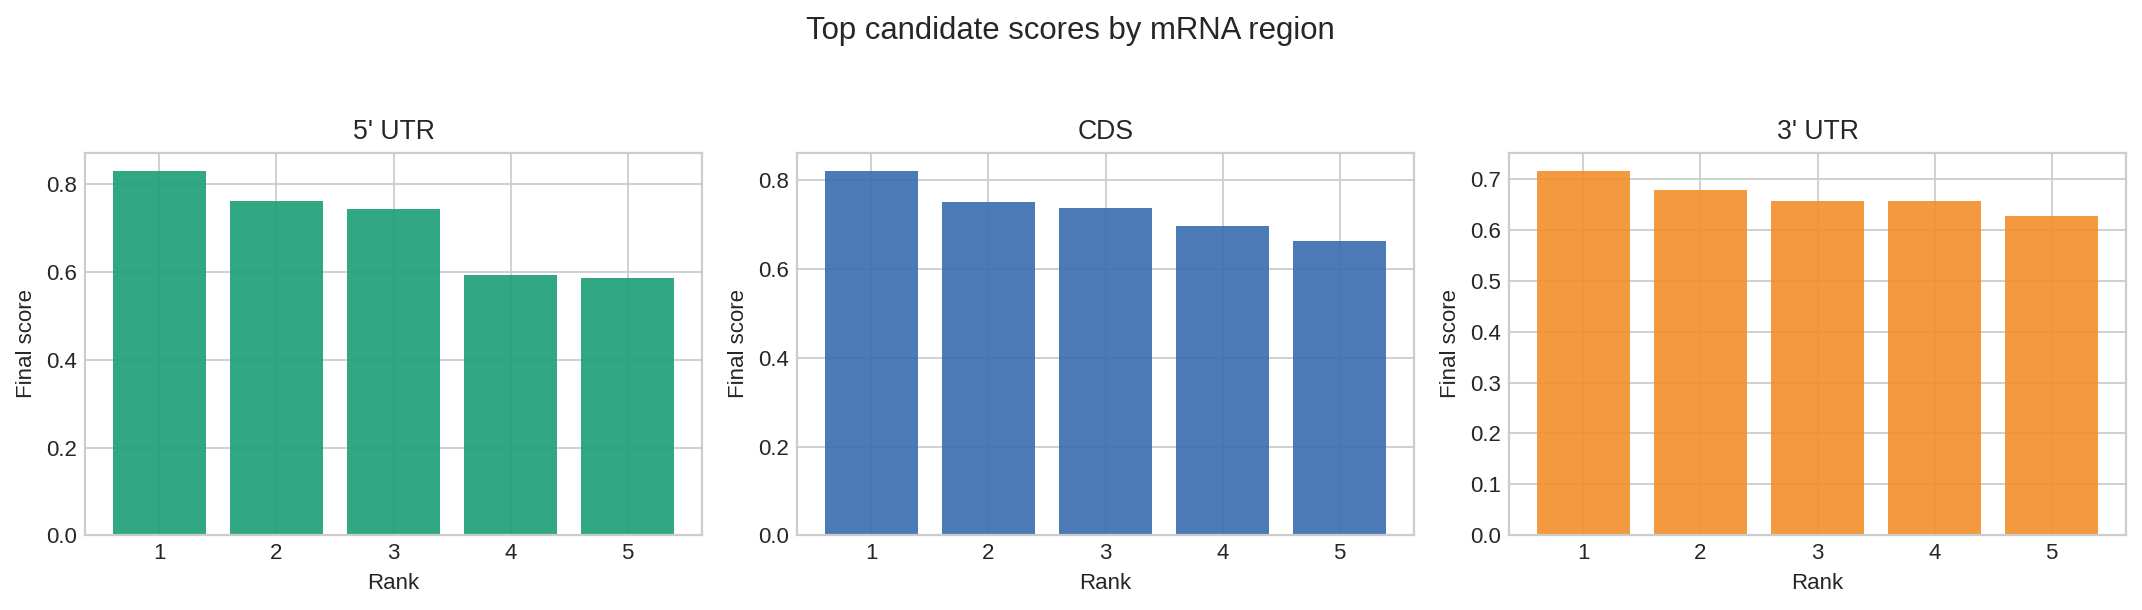

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
colors = {"5' UTR": "#1b9e77", "CDS": "#386cb0", "3' UTR": "#f28e2b"}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=False)
for ax, (region, table) in zip(axes, summary.groupby("region", sort=False)):
    ax.bar(table["rank"].astype(str), table["final_score"], color=colors[region], alpha=0.9)
    ax.set_title(region)
    ax.set_xlabel("Rank")
    ax.set_ylabel("Final score")
    ax.set_ylim(bottom=min(0, table["final_score"].min() * 0.95))
fig.suptitle("Top candidate scores by mRNA region", y=1.05, fontsize=14)
fig.tight_layout()
plt.show()


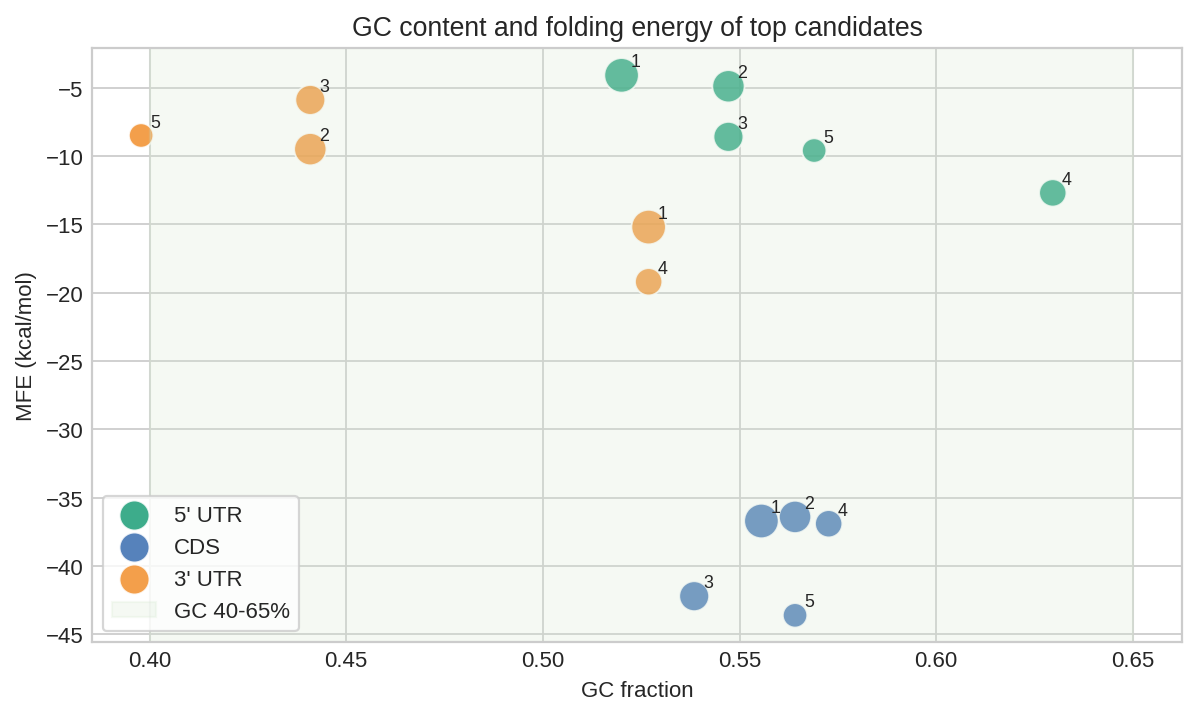

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for region, table in summary.groupby("region", sort=False):
    scatter = ax.scatter(
        table["gc"],
        table["mfe"],
        s=90 + 30 * (6 - table["rank"]),
        color=colors[region],
        label=region,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.8,
    )
    for _, row in table.iterrows():
        ax.annotate(int(row["rank"]), (row["gc"], row["mfe"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.axvspan(0.40, 0.65, color="#d8ead3", alpha=0.25, label="GC 40-65%")
ax.set_xlabel("GC fraction")
ax.set_ylabel("MFE (kcal/mol)")
ax.set_title("GC content and folding energy of top candidates")
ax.legend(frameon=True, loc="best")
fig.tight_layout()
plt.show()


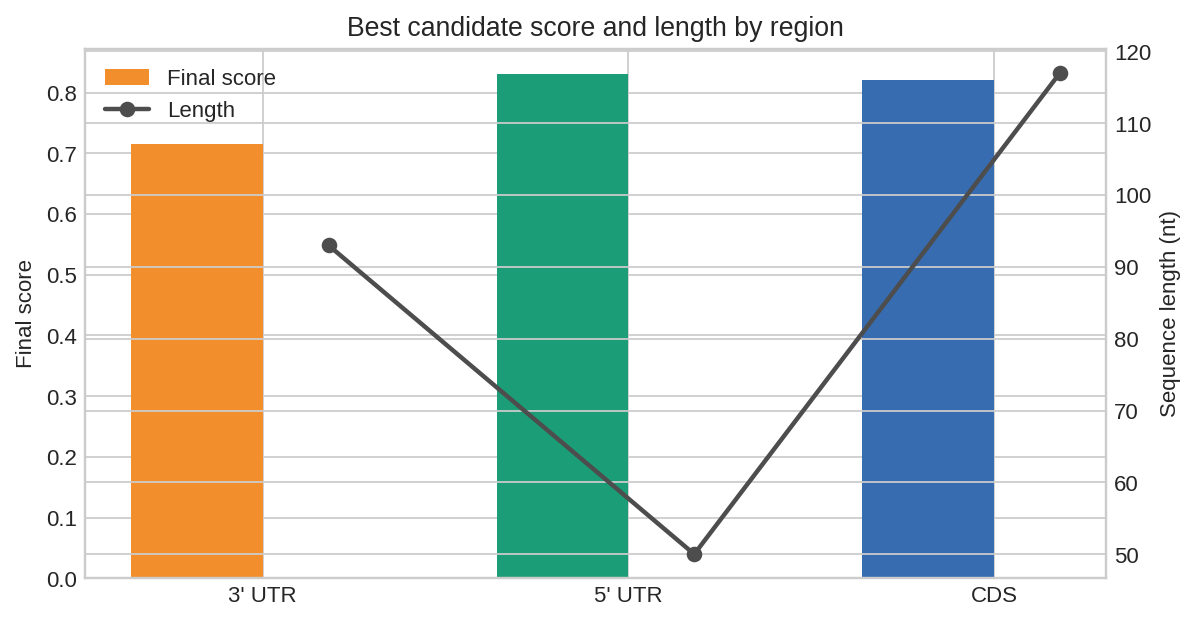

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 4.0))
best_plot = best.copy()
labels = best_plot["region"].tolist()
x = np.arange(len(labels))
ax.bar(x - 0.18, best_plot["final_score"], width=0.36, color=[colors[r] for r in labels], label="Final score")
ax2 = ax.twinx()
ax2.plot(x + 0.18, best_plot["length"], marker="o", color="#4d4d4d", linewidth=2, label="Length")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Final score")
ax2.set_ylabel("Sequence length (nt)")
ax.set_title("Best candidate score and length by region")
lines, line_labels = ax.get_legend_handles_labels()
lines2, line_labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, line_labels + line_labels2, loc="upper left")
fig.tight_layout()
plt.show()


## 7. Output files


In [9]:
for region, cfg in TASKS.items():
    print(f"{region}: {cfg['top_csv'].relative_to(PROJECT_ROOT)}")


5' UTR: outputs/generation/5utr_demo/demo_5utr_top5.csv
CDS: outputs/generation/cds_demo/top10_generated_scored.csv
3' UTR: outputs/generation/3utr_demo/demo_3utr_top5.csv
